<a href="https://colab.research.google.com/github/GEE2007/spotify-genre-classification/blob/main/spotify_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** - Geetika

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/GEE2007/spotify-genre-classification

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [4]:
# Load Dataset
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "spotify-tracks-dataset-detailed.csv"))

Using Colab cache for faster access to the 'spotify-tracks-dataset-audio-features' dataset.
Path to dataset files: /kaggle/input/spotify-tracks-dataset-audio-features
['spotify-tracks-dataset-detailed.csv']


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(114000, 20)

In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
df = df.sample(n=20000, random_state=42)

### Dataset Information

In [12]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 113186 to 17149
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          20000 non-null  object 
 1   artists           20000 non-null  object 
 2   album_name        20000 non-null  object 
 3   track_name        20000 non-null  object 
 4   popularity        20000 non-null  int64  
 5   duration_ms       20000 non-null  int64  
 6   explicit          20000 non-null  bool   
 7   danceability      20000 non-null  float64
 8   energy            20000 non-null  float64
 9   key               20000 non-null  int64  
 10  loudness          20000 non-null  float64
 11  mode              20000 non-null  int64  
 12  speechiness       20000 non-null  float64
 13  acousticness      20000 non-null  float64
 14  instrumentalness  20000 non-null  float64
 15  liveness          20000 non-null  float64
 16  valence           20000 non-null  float6

#### Duplicate Values

In [23]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(17)

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


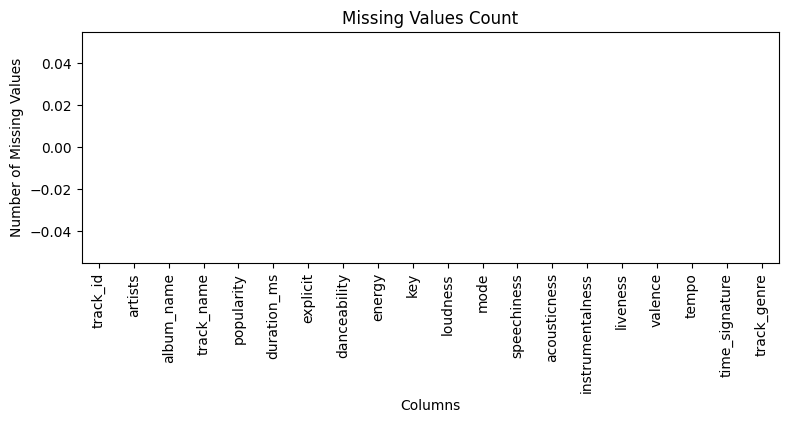

In [15]:
# Visualizing the missing values
df.isnull().sum().plot(kind='bar', figsize=(9,3))
plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

### What did you know about your dataset?

* *The dataset contains 20,000 songs and 20 columns after random sampling from the original dataset.*
* *It includes information such as artist name, album name, track name, popularity, duration, danceability, energy, loudness, tempo, and other audio features.*
* *The target variable is track_genre, which represents the genre of each song.*
* *The dataset contains different data types including numerical, categorical, and boolean features.*
* *It is a multiclass classification dataset because it contains multiple music genres.*

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [18]:
# Dataset Describe
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,33.199700,2.269323e+05,0.567058,0.642218,5.28175,-8.246955,0.642000,0.084663,0.314074,0.158173,0.213357,0.475482,122.163859,3.89975
std,22.241833,9.738991e+04,0.174293,0.252224,3.54790,5.031660,0.479424,0.105436,0.331604,0.311655,0.189525,0.259418,30.058054,0.44532
min,0.000000,2.124000e+04,0.000000,0.000020,0.00000,-43.943000,0.000000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,0.00000
25%,17.000000,1.730588e+05,0.454000,0.472000,2.00000,-10.012500,0.000000,0.035800,0.016500,0.000000,0.098300,0.262000,99.777500,4.00000
50%,35.000000,2.125130e+05,0.581000,0.687000,5.00000,-6.983000,1.000000,0.048800,0.168000,0.000045,0.132000,0.465000,122.001500,4.00000
75%,50.000000,2.609340e+05,0.698000,0.855000,8.00000,-4.999000,1.000000,0.084125,0.595000,0.052225,0.275000,0.685000,140.028250,4.00000
max,100.000000,3.600120e+06,0.984000,1.000000,11.00000,4.532000,1.000000,0.965000,0.996000,0.999000,0.995000,0.993000,220.084000,5.00000


### Variables Description

* *track_id: Unique ID assigned to each Spotify track.*
* *artists: Name of the artist or artists who performed the song.*
* *album_name: Name of the album in which the song appears.*
* *track_name: Name of the song.*
* *popularity: Popularity score of the song ranging from 0 to 100.*
* *duration_ms: Duration of the song in milliseconds.*
* *explicit: Indicates whether the song contains explicit lyrics (True/False).*
* *danceability: Measures how suitable the song is for dancing. Values range from 0 to 1.*
* *energy: Represents the intensity and activity level of the song. Values range from 0 to 1.*
* *key: Musical key in which the song is composed (values from 0 to 11).*
* *loudness: Overall loudness of the song measured in decibels (dB).*
* *mode: Indicates whether the song is in Major (1) or Minor (0) mode.*
* *speechiness: Measures the presence of spoken words in the song. Values range from 0 to 1.*
* *acousticness: Measures how acoustic the song is. Values range from 0 to 1.*
* *instrumentalness: Predicts whether the song contains no vocals. Values range from 0 to 1.*
* *liveness: Measures the likelihood that the song was performed live. Values range from 0 to 1.*
* *valence: Describes the musical positivity or happiness of the song. Values range from 0 to 1.*
* *tempo: Estimated speed of the song measured in beats per minute (BPM).*
* *time_signature: Indicates the number of beats in each musical measure.*
* *track_genre: Represents the genre of the song. This is the target variable used for multiclass classification.*

### Check Unique Values for each variable.

In [19]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

track_id: 19016
artists: 10709
album_name: 13644
track_name: 17190
popularity: 98
duration_ms: 15077
explicit: 2
danceability: 939
energy: 1370
key: 12
loudness: 10110
mode: 2
speechiness: 1271
acousticness: 3732
instrumentalness: 4074
liveness: 1564
valence: 1517
tempo: 14304
time_signature: 5
track_genre: 114


## 3. ***Data Wrangling***

### Data Wrangling Code

In [25]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### What all manipulations have you done and insights you found?

* *Shuffled the dataset randomly to remove the original genre-wise ordering.*
* *Selected a random sample of 20,000 records from the original dataset to reduce computation time while maintaining data diversity.*
* *Reset the index after sampling to keep the dataset organized.
Checked for missing values and found no missing values, so no treatment was required.*
* *Checked for duplicate records and found 17 duplicate rows. Since they were a very small portion of the dataset (17 out of 20,000), they were removed to improve data quality.*
* *Checked the unique values of each feature to better understand the dataset.*

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***